In [1]:
import numpy as np
import pysindy as ps
import sympy as sym
import matplotlib.pyplot as plt
import math

In [60]:
'''
    Function that defines stimulus with 3 sets of stim_count pulses, each with decreasing period.
    Params:
        t (array): Time values
        dur (float): Duration of each pulse
        mag (float): Magnitude of the stimulus
        stim_count (int): Number of stimuli of each period to generate
        periods (array): Array of periods for each set of pulses
'''
def func_pacedown(t, dur=5.0, mag=0.12, stim_count=3, periods = np.array([305., 230., 155.])):
    period_0_multiple = np.minimum(np.floor(t / periods[0]), stim_count)
    period_1_multiple = np.minimum(np.floor((t - period_0_multiple * periods[0]) / periods[1]), stim_count)
    period_2_multiple = np.minimum(np.floor((t - period_0_multiple * periods[0] - period_1_multiple * periods[1]) / periods[2]), stim_count)

    local_t_0 = t
    local_t_1 = t - stim_count * periods[0]
    local_t_2 = t - stim_count * periods[0] - stim_count * periods[1]

    is_stim = np.zeros_like(t, dtype=bool)

    mask_0 = period_0_multiple < stim_count
    mask_1 = (~mask_0) & (period_1_multiple < stim_count)
    mask_2 = (~mask_0) & (~mask_1) & (period_2_multiple < stim_count)

    stim_0 = np.mod(local_t_0, periods[0]) <= dur
    stim_1 = np.mod(local_t_1, periods[1]) <= dur
    stim_2 = np.mod(local_t_2, periods[2]) <= dur

    # Use np.where to allow both scalar and array t to work.
    is_stim = np.where(
        mask_0,
        stim_0,
        np.where(mask_1,
                 stim_1,
                 np.where(mask_2,
                          stim_2,
                          False))
    )

    stimulus = mag * is_stim
    return stimulus

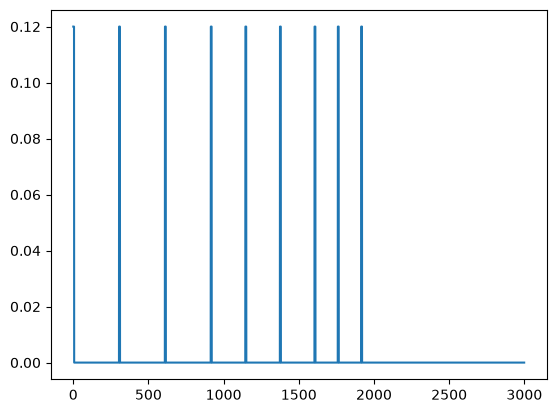

In [62]:
t = np.arange(0, 3000.0, 1.0)
plt.plot(t, func_pacedown(t))

In [2]:
monomial_names = ['u', 'u**2', 'u**3', 'v', '1', 'ft_d']

# Define symbols
u, v, ft_d = sym.symbols('u v ft_d')

# Ensure monomial term names match those used in the equations.
if 'ft_d(t)' in monomial_names:
    monomial_names[monomial_names.index('ft_d(t)')] = 'ft_d'

print(f"Edited monomial names: {monomial_names}")


params = dict(alpha=0.1, beta=0.5, gamma=1, delta=0.0, eps=0.01)
u_rhs = u*(1-u)*(u-params['alpha']) - v + ft_d
v_rhs = params['eps']*(params['beta']*u - params['gamma']*v - params['delta'])

# Expand and collect coefficients
u_rhs_exp = sym.expand(u_rhs).as_poly(u, v, ft_d)
v_rhs_exp = sym.expand(v_rhs).as_poly(u, v, ft_d)
m_sym = [sym.sympify(m) for m in monomial_names]
u_coeffs = [float(u_rhs_exp.coeff_monomial(m)) for m in m_sym]
print(u_rhs_exp)
print(u_coeffs)

Edited monomial names: ['u', 'u**2', 'u**3', 'v', '1', 'ft_d']
Poly(-1.0*u**3 + 1.1*u**2 - 0.1*u - 1.0*v + 1.0*ft_d, u, v, ft_d, domain='RR')
[-0.1, 1.1, -1.0, -1.0, 0.0, 1.0]


In [3]:
# Define variable-specific functions
position_functions = [
    lambda x: x,           # linear
    lambda x: x**2,        # quadratic
    lambda x: x**3         # cubic
]

velocity_functions = [
    lambda x: x,           # linear
    lambda x: np.sin(x),   # sinusoidal
    lambda x: np.cos(x)    # cosinusoidal
]

acceleration_functions = [
    lambda x: x,           # linear
    lambda x: np.exp(-x),  # exponential decay
    lambda x: np.log(np.abs(x) + 1)  # logarithmic
]

In [4]:
# Create variable-specific library
position_library = ps.CustomLibrary(library_functions=position_functions,
                                    function_names=[lambda x: x, lambda x: x + '^2', lambda x: x + '^3'])
velocity_library = ps.CustomLibrary(library_functions=velocity_functions,
                                    function_names=[lambda x: x, lambda x: 'sin(' + x + ')', lambda x: 'cos(' + x + ')'])
acceleration_library = ps.CustomLibrary(library_functions=acceleration_functions,
                                         function_names=[lambda x: x, lambda x: 'e^(-' + x + ')', lambda x: 'log(|' + x + '|+1)'])
gen_library = ps.GeneralizedLibrary([position_library, velocity_library, acceleration_library])

# Generate sample data
t = np.linspace(0, 10, 1000)
x = np.column_stack([
    np.sin(t),           # position-like variable
    np.cos(t),           # velocity-like variable  
    -np.sin(t)           # acceleration-like variable
])

print(x.shape)
print(t.shape)

(1000, 3)
(1000,)


In [5]:
# Fit SINDy model
out = gen_library.fit(x)
out = gen_library.transform(x)
print(out.shape)
print(out)

# Print the equations from the SINDy fit
model = ps.SINDy(feature_library=gen_library, optimizer=ps.SSR(alpha=0.00001))
model.fit(x, t=t) # feature_names=["x", "x\'", "x\'\'"]
model.print(precision=5)

(1000, 27)
[[ 0.          1.         -0.         ...  0.          0.69314718
   0.        ]
 [ 0.01000984  0.9999499  -0.01000984 ...  0.00996008  0.69312213
   0.00996008]
 [ 0.02001868  0.99979961 -0.02001868 ...  0.01982094  0.69304698
   0.01982094]
 ...
 [-0.52711499 -0.84979397  0.52711499 ...  0.42338033  0.61507427
   0.42338033]
 [-0.53559488 -0.84447506  0.53559488 ...  0.42891785  0.61219472
   0.42891785]
 [-0.54402111 -0.83907153  0.54402111 ...  0.43439012  0.60926084
   0.43439012]]
(x0)' =  0.33361 x1 +  2.41928 x0^2 +  4.30127 x1^2 +  2.41928 x2^2 + -0.00365 x1^3 +  0.33361 x1 + -0.01139 sin(x1) +  0.09131 cos(x0) +  11.83149 cos(x1) +  0.09131 cos(x2) +  0.33361 x1 + -5.43011 e^(-x0) + -0.01054 e^(-x1) + -5.43011 e^(-x2)
(x1)' = -0.16676 x0 +  0.16676 x2 +  0.00008 x0^2 +  0.00118 x0^3 + -0.00118 x2^3 + -0.16676 x0 +  0.16676 x2 +  0.00368 sin(x0) + -0.00368 sin(x2) +  0.00008 cos(x0) + -0.16676 x0 +  0.16676 x2 +  0.00335 e^(-x0) + -0.00343 e^(-x2)
(x2)' = -0.33361 x

In [6]:
a = sym.Rational(1,2) + sym.Rational(1,3)
print(a)
a.evalf()

5/6


0.833333333333333